In [128]:
# import sys

# print(sys.executable)

# import sys
# import numpy as np

# print("Python:", sys.executable)
# print("NumPy:", np.__version__)

# import pkg_resources

# for p in ["tensorflow", "numpy", "mediapipe", "jax", "jaxlib"]:
#     try:
#         print(p, pkg_resources.get_distribution(p).version)
#     except:
#         print(p, "NOT INSTALLED")

# import tensorflow as tf
# print(tf.__version__)

# import mediapipe as mp

# mp_holistic = mp.solutions.holistic
# mp_drawing = mp.solutions.drawing_utils

# print("Holistic loaded successfully")

In [129]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [130]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

In [131]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  #Color conversion BGR to RGB
    image.flags.writeable = False                   #Image is no longer writeable

    results = model.process(image)                  #Make prediction

    image.flags.writeable = True                    #Image is now writeable
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)  #Color conversion RGB to BGR

    return image, results

In [132]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION)        #Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)        #Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)   #Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)  #Draw right hand connections

In [133]:
def draw_styled_landmarks(image, results):
    #Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    #Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    #Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    #Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             )

In [134]:
# mp_drawing.draw_landmarks??

In [135]:
# cap = cv2.VideoCapture(0)
# #Set mediapipe model
# with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
#     while cap.isOpened():
#             #Read feed
#             ret, frame = cap.read()

#             #Make detections
#             image, results = mediapipe_detection(frame, holistic)
#             # print(results)

#             #Draw landmarks
#             draw_styled_landmarks(image, results)

#             #Show feed
#             cv2.imshow("OpenCV Feed", image)

#             #Break
#             if cv2.waitKey(10) & 0xFF == ord('q'):
#                 break

# cap.release()
# cv2.destroyAllWindows()

In [136]:
# len(results.face_landmarks.landmark)

In [137]:
# frame

In [138]:
# draw_landmarks(frame, results)

In [139]:
# plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [140]:
# results??
# results.pose_landmarks.landmark
# len(results.pose_landmarks.landmark)


In [141]:
# results.pose_landmarks.landmark[0]

In [142]:
# pose = []
# for res in results.pose_landmarks.landmark:
#     test = np.array([[res.x, res.y, res.z, res.visibility]])
#     pose.append(test)

In [143]:
# pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
# face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
# lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3) 
# rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)   

In [144]:
# len(pose)
# pose.shape 
# face.shape

In [428]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3) 
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)   
    return np.concatenate([pose, face, lh, rh])

In [146]:
# result_test = extract_keypoints(results)

In [147]:
# result_test

In [148]:
# np.save('0', result_test)

In [149]:
# np.load('0.npy')

In [ ]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join("MP_Data")

# Actions that we try to detect
actions = np.array(['Hello', 'Thanks', 'I love you','Yes','No','Please','Father','Mother','Nice to meet you', 'How are you'])



# The number of videos we want to collect per sign
no_sequences = 50
# Videos are going to be 30 frames in length
sequence_length = 40

In [430]:
for action in actions:
    for sequence in range(no_sequences):
        try:
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

In [332]:
cap = cv2.VideoCapture(0)
#Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            #Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                #Read feed
                ret, frame = cap.read()

                #Make detections
                image, results = mediapipe_detection(frame, holistic)
                # print(results)

                #Draw landmarks
                draw_styled_landmarks(image, results)

                #Apply collection logic
                if frame_num == 0:
                    cv2.putText(image, "STARTING COLLECTION", (120,200),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, f'Collecting frames for {action} Video Number {sequence}', 
                                (15,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255, 0), 1, cv2.LINE_AA)
                    cv2.waitKey(2000)
                else:                 
                    cv2.putText(image, f'Collecting frames for {action} Video Number {sequence}', 
                                (15,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255, 0), 1, cv2.LINE_AA)
                # New export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                #Show feed
                cv2.imshow("OpenCV Feed", image)

                #Break
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break

cap.release()
cv2.destroyAllWindows()

In [ ]:
# cap.release()
# cv2.destroyAllWindows()

In [335]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical   


In [336]:
label_map = {label:num for num, label in enumerate(actions)}

In [337]:
label_map

{'Hello': 0,
 'Thanks': 1,
 'I love you': 2,
 'See you later': 3,
 'I want to eat': 4,
 'How are you': 5,
 'Father': 6,
 'Mother': 7,
 'Nice to meet you': 8}

In [338]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [434]:
np.array(sequences).shape

(270, 30, 1662)

In [340]:
np.array(labels).shape

(270,)

In [397]:
x = np.array(sequences)
x.shape

(270, 30, 1662)

In [398]:
y = to_categorical(labels).astype(int)
y

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]])

In [399]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.05)

In [400]:
y_train.shape

(256, 9)

In [401]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense 
from tensorflow.keras.callbacks import TensorBoard

In [402]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [403]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

c:\Users\amira\OneDrive\Documents\PROJECT\SIGN_LANGUAGE_DETECTION\SLD_1\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [404]:
# actions.shape[0]
# res = [0.5,0.3,0.1]
# actions[np.argmax(res)]

In [405]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=220, callbacks=[tb_callback])

Epoch 1/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - categorical_accuracy: 0.1406 - loss: 22.9543
Epoch 2/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - categorical_accuracy: 0.1055 - loss: 24.8768
Epoch 3/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - categorical_accuracy: 0.0977 - loss: 92.3986
Epoch 4/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - categorical_accuracy: 0.1016 - loss: 80.7352 
Epoch 5/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - categorical_accuracy: 0.1172 - loss: 30.4055
Epoch 6/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - categorical_accuracy: 0.1367 - loss: 20.8846
Epoch 7/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - categorical_accuracy: 0.0898 - loss: 7.5620
Epoch 8/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - categorical_accuracy: 0.0742 - loss: 4.8147
Epoch 9/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - categorical_accuracy: 0.1172 - loss: 3.2523
Epoch 10/220
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - categorical_accuracy: 0.1562 - loss: 3.0829
Epoch 11/220
8/8 ━━━━━━━━━━━━━━━

In [409]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 30, 64)         │       442,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,790,621 (6.83 MB)

 Trainable params: 596,873 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,193,748 (4.55 MB)

In [438]:
res = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [439]:
# res[0]
# array([4.4381748e-05, 9.9853885e-01, 1.8484606e-07, 9.5031220e-07,
#        1.0444003e-03, 3.7127594e-04, 2.2387714e-09, 2.1233095e-08,
#        1.5981783e-09, 1.0154953e-14], dtype=float32)

np.sum(res[0])

1.0

In [440]:
actions[np.argmax(res[7])]

'Father'

In [441]:
actions[np.argmax(res[7])]

'Father'

In [414]:
model.save('action.h5')

In [415]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score


In [442]:
yhat = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [443]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [444]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[10,  3],
        [ 1,  0]],

       [[13,  0],
        [ 0,  1]],

       [[12,  0],
        [ 1,  1]],

       [[10,  1],
        [ 2,  1]],

       [[12,  0],
        [ 0,  2]],

       [[13,  0],
        [ 0,  1]],

       [[11,  3],
        [ 0,  0]],

       [[11,  0],
        [ 3,  0]],

       [[13,  0],
        [ 0,  1]]], dtype=int64)

In [445]:
# multilabel_confusion_matrix??

In [446]:
accuracy_score(ytrue, yhat)

0.5

In [447]:
x_test[0].shape

(30, 1662)

In [448]:
# model.predict(x_test)      -> shape should be (number of sequences,30 ,1662) 
# model.predict(x_test)  #     -> Works fine as shape matches
# model.predict(x_test[0]) # -> Does not work as shape does not match, expected (1, 30,1662) but got (30, 1662)
# So
# model.predict(np.expand_dims(x_test[0], axis=0))

In [462]:
colors = [
    (245,117,16),
    (117,245,16),
    (16,117,245),
    (255,0,0),
    (255,255,0),
    (255,0,255),
    (0,255,255),
    (128,0,255),
    (0,128,255)
]

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()

    start_y = 60
    row_height = 50
    bar_max_width = 300

    for num, prob in enumerate(res):
        y1 = start_y + num * row_height
        y2 = y1 + 30

        color = colors[num % len(colors)]

        cv2.rectangle(
            output_frame,
            (10, y1),
            (10 + int(prob * bar_max_width), y2),
            color,
            -1
        )

        cv2.putText(
            output_frame,
            f"{actions[num]}: {prob:.2f}",
            (320, y2 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

    return output_frame

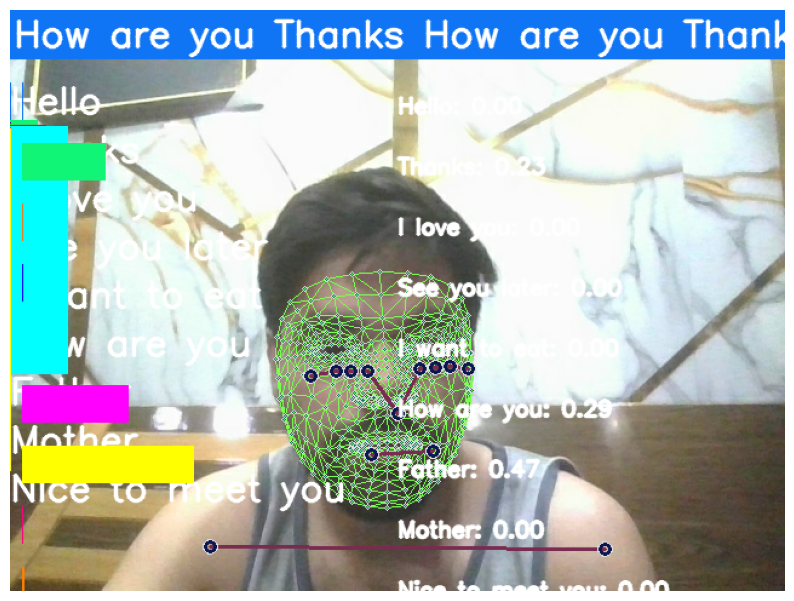

In [463]:
plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(prob_viz(res, actions, image, colors), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [465]:
#New detection variable
sequence = []
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
#Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
            #Read feed
            ret, frame = cap.read()

            #Make detections
            image, results = mediapipe_detection(frame, holistic)
            # print(results)

            #Draw landmarks
            draw_styled_landmarks(image, results)

            # 2. Prediction logic
            keypoints = extract_keypoints(results)
            sequence.append(keypoints)
            sequence = sequence[-30:]

            if len(sequence) == 30:
                res = model.predict(np.expand_dims(sequence, axis=0), verbose=0)[0]
                print(actions[np.argmax(res)])
                predictions.append(np.argmax(res))

                if np.unique(predictions[-10:])[0] == np.argmax(res):
                    if res[np.argmax(res)] > threshold:
                        if len(sentence) > 0:
                            if actions[np.argmax(res)] != sentence[-1]:
                                sentence.append(actions[np.argmax(res)])
                        else:
                            sentence.append(actions[np.argmax(res)])
        
            if len(sentence) > 5:
                 sentence = sentence[-5:]

            #Viz probabilities
            # image = prob_viz(res, actions, image, colors) #-> for real time probability calculation
                           
            cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
            cv2.putText(image, ' '.join(sentence), (3,30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)

            #Show feed
            cv2.imshow("OpenCV Feed", image)

            #Break
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

cap.release()
cv2.destroyAllWindows()

c:\Users\amira\OneDrive\Documents\PROJECT\SIGN_LANGUAGE_DETECTION\SLD_1\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Father
Father
Hello
Father
Hello
Hello
Hello
Father
Hello
Father
Hello
Hello
Hello
Hello
Hello
See you later
See you later
See you later
See you later
See you later
See you later
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
See you later
Hello
Hello
Hello
I love you
Hello
Mother
Hello
See you later
See you later
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
See you later
See you later
See you later
See you later
See you later
Hello
See you later
See you later
See you later
See you later
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Hello
Father
Thanks
Thanks
Thanks
Thanks
Thanks
Thanks
Thanks
Thanks
Father
Thanks
Father
Hello
Father
Hello
Hello
Hello
Hello
Father
Thanks
Father
Thanks
Father
Father
Father
Hello
Father
Father
Hello
Father
Father
Father
Father
Father
Father
Father
Father
Father
Father
Father
Father
Thanks
Thanks
Thanks
Thanks
Thanks
Thanks
Thanks
Thanks
Thanks
Father
Thanks
Thanks
Thanks
Thanks
Thanks
Thanks
Father
Th